Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [12]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Cleaning

In [9]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

In [10]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Check for Duplicate Rows

In [13]:
# Total duplicate rows
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis (EDA)

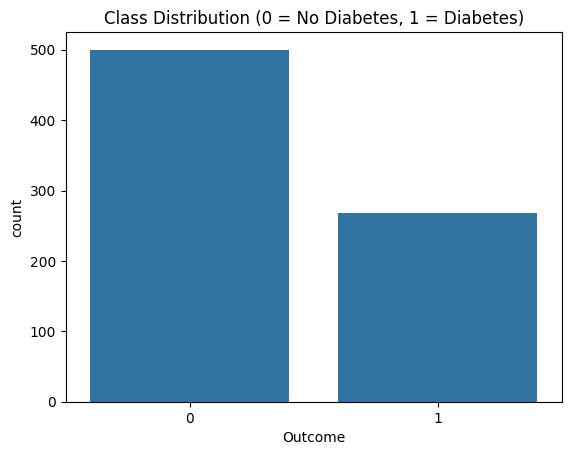

In [14]:
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()

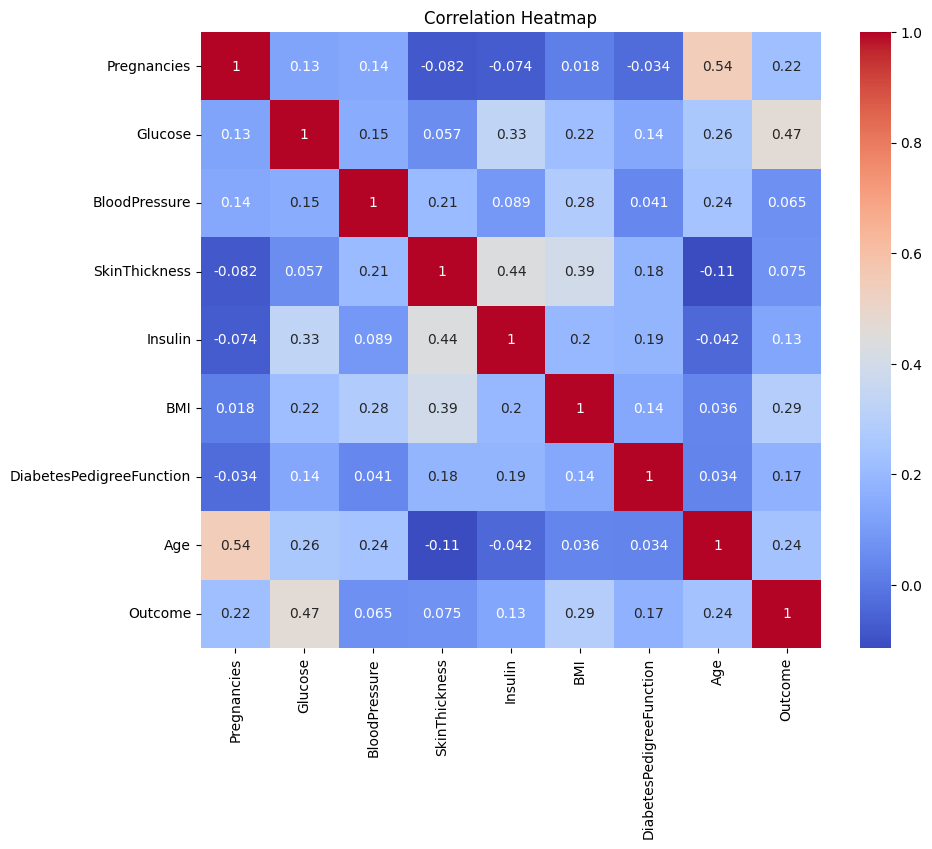

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

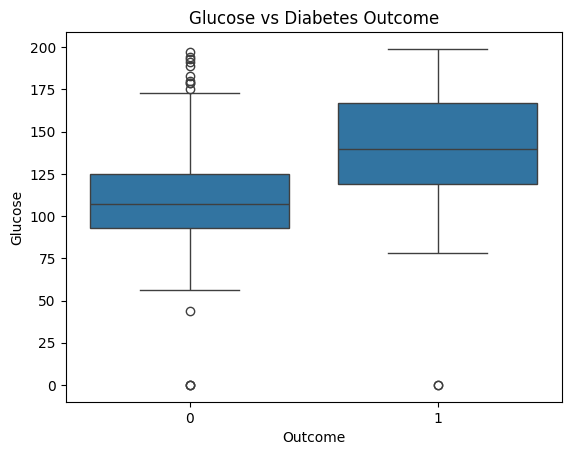

In [16]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

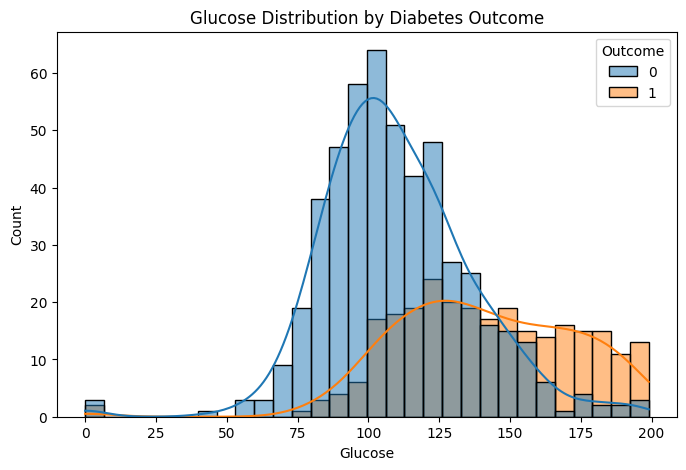

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True, bins=30)
plt.title("Glucose Distribution by Diabetes Outcome")
plt.show()

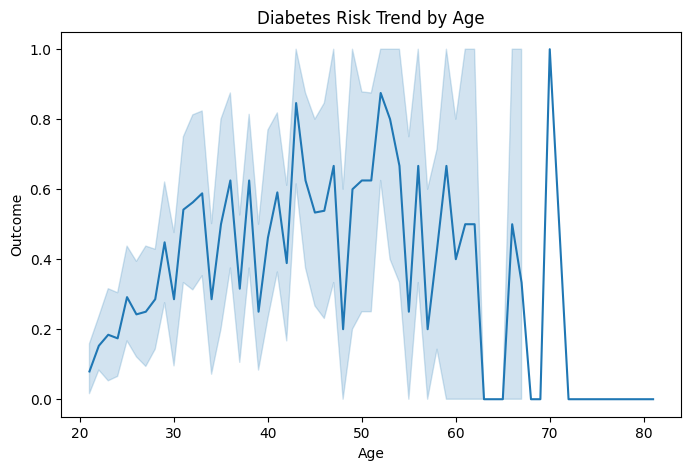

In [19]:
plt.figure(figsize=(8,5))
sns.lineplot(x="Age", y="Outcome", data=df)
plt.title("Diabetes Risk Trend by Age")
plt.show()

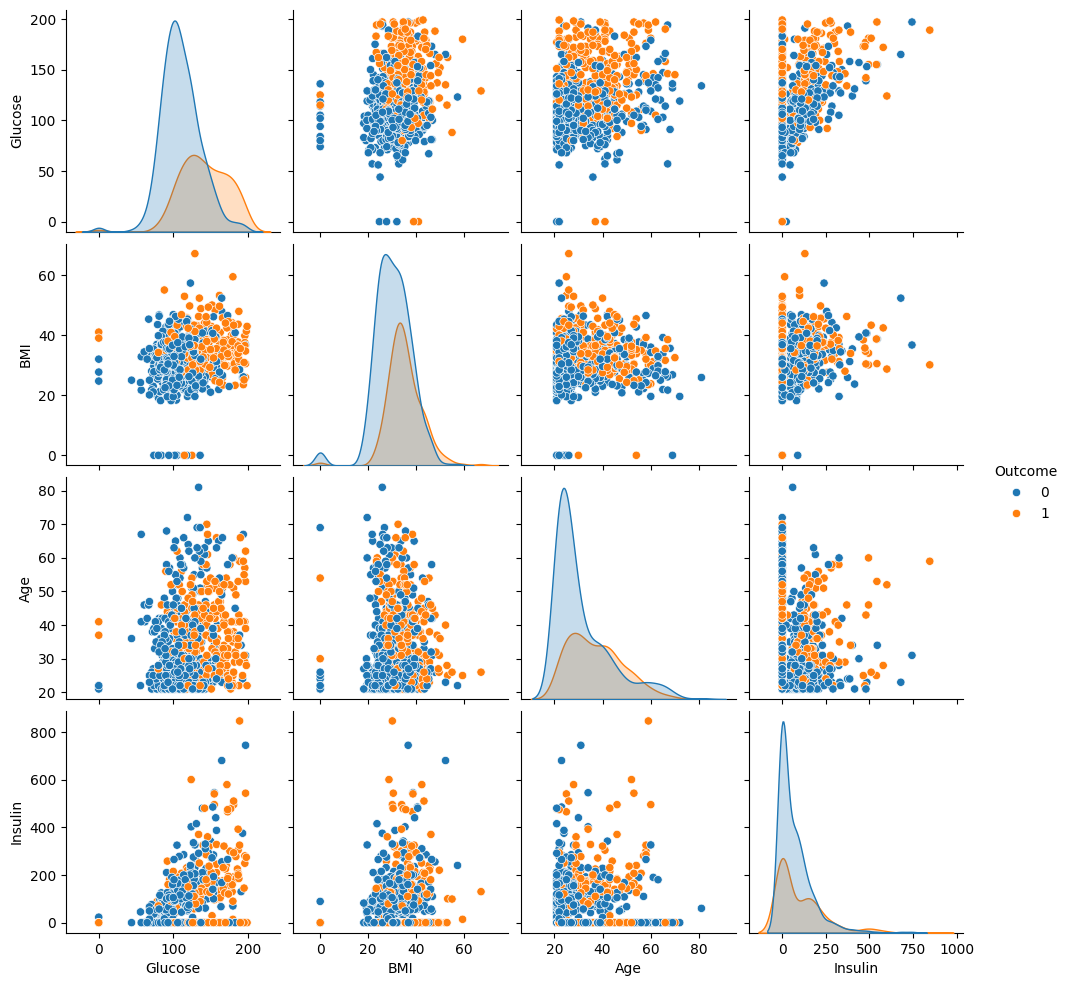

In [20]:
sns.pairplot(df, hue="Outcome", vars=["Glucose", "BMI", "Age", "Insulin"])
plt.show()

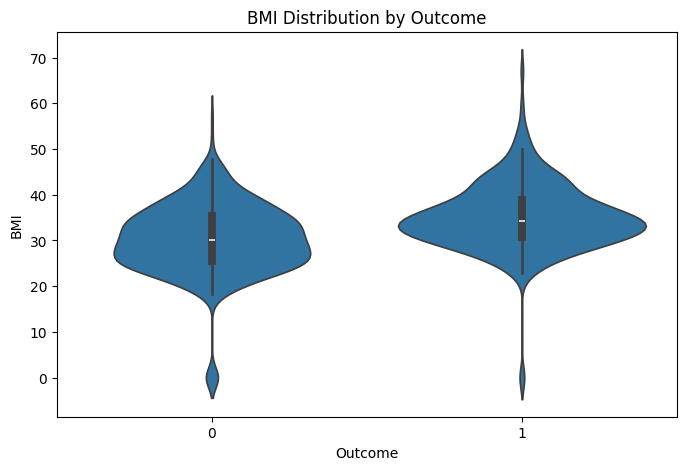

In [21]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Outcome", y="BMI", data=df)
plt.title("BMI Distribution by Outcome")
plt.show()

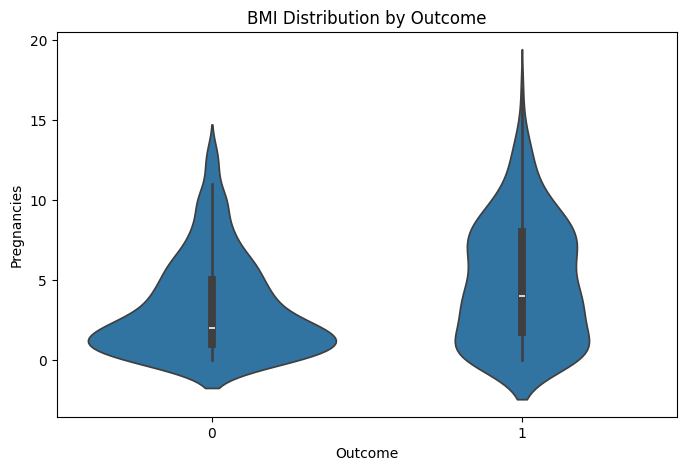

In [23]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Outcome", y="Pregnancies", data=df)
plt.title("BMI Distribution by Outcome")
plt.show()

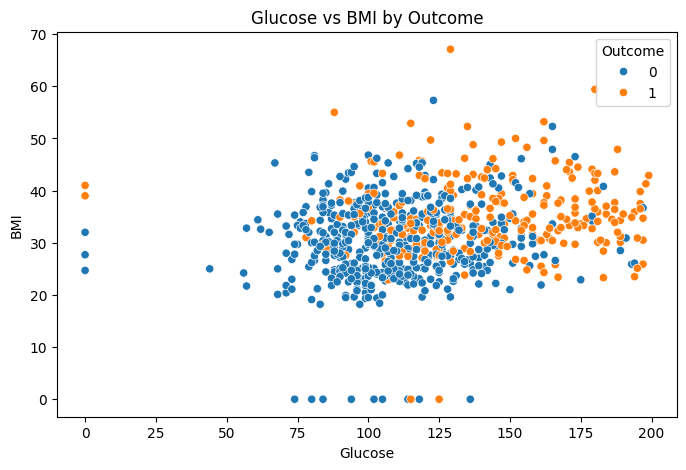

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome")
plt.title("Glucose vs BMI by Outcome")
plt.show()

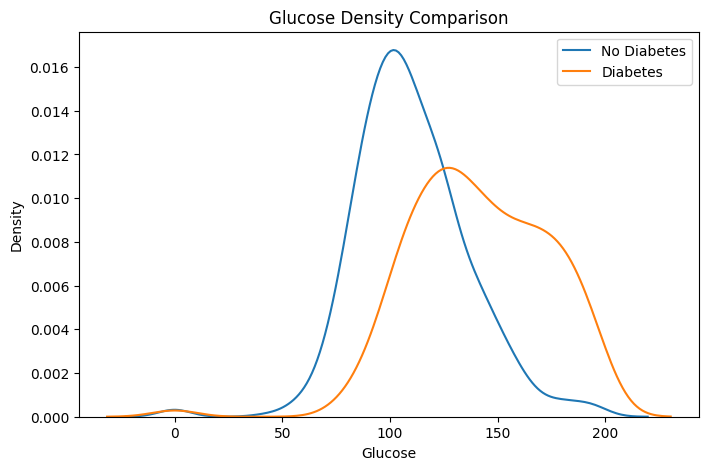

In [25]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df["Outcome"]==0]["Glucose"], label="No Diabetes")
sns.kdeplot(data=df[df["Outcome"]==1]["Glucose"], label="Diabetes")
plt.legend()
plt.title("Glucose Density Comparison")
plt.show()

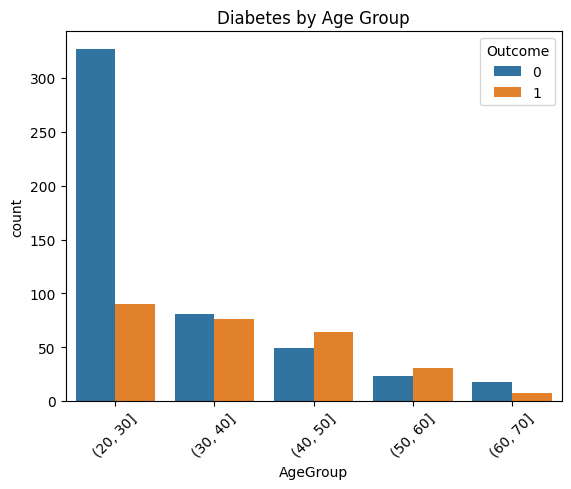

In [26]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[20,30,40,50,60,70])
sns.countplot(x="AgeGroup", hue="Outcome", data=df)
plt.xticks(rotation=45)
plt.title("Diabetes by Age Group")
plt.show()

Prepare Data for Modeling

In [35]:
df = df.drop("AgeGroup", axis=1)

In [37]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Model Evaluation

In [47]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82        99
           1       0.68      0.58      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



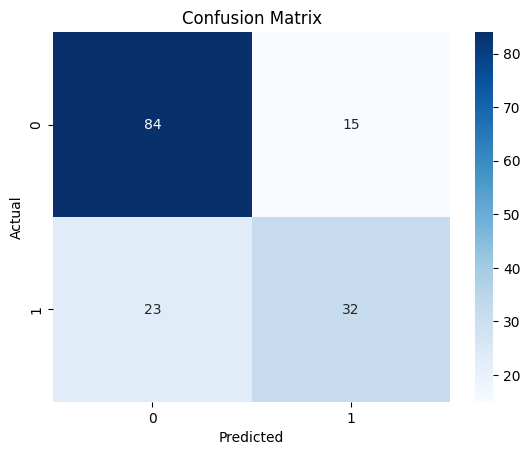

In [48]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance (Logistic Coefficients)

In [49]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
1,Glucose,4.396536
5,BMI,3.296852
7,Age,1.721651
6,DiabetesPedigreeFunction,1.125278
0,Pregnancies,0.963849
3,SkinThickness,0.216119
4,Insulin,-0.307031
2,BloodPressure,-0.570579
